# Ridge Regularization

### Loading and splitting dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [3]:
data.DESCR

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [4]:
x = data.data
y = data.target

In [5]:
x.shape

(442, 10)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)

### Apply on Linear Regression model

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = lr.predict(x_test)

In [12]:
from sklearn.metrics import r2_score, mean_squared_error

In [13]:
print(f'R2 Score: {r2_score(y_test, y_pred)}')
print(f'Root mean squared error: {np.sqrt(mean_squared_error(y_test, y_pred))}')

R2 Score: 0.3852693902152976
Root mean squared error: 55.751278769977965


### Do using Ridge Regularization

In [14]:
from sklearn.linear_model import Ridge

In [15]:
rdg = Ridge(alpha=0.00001)

In [16]:
rdg.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1e-05
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None

In [17]:
y_pred1 = rdg.predict(x_test)

In [18]:
print(f'R2 Score: {r2_score(y_test, y_pred1)}')
print(f'Root mean squared error: {np.sqrt(mean_squared_error(y_test, y_pred1))}')

R2 Score: 0.3852661903624012
Root mean squared error: 55.75142387065772


### Creation of a dataset for testing of model

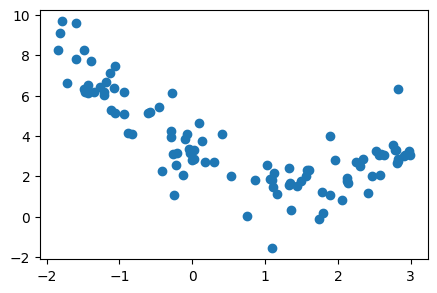

In [23]:
m = 100
x1 = 5*np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2*x1 + 3+np.random.randn(m, 1)

plt.figure(figsize=(5,3.24))
plt.scatter(x1, x2)
plt.show()

### Creating function for finding prediction

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):

    model = Pipeline([
        ('poly_feature', PolynomialFeatures(degree=8)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

In [34]:
alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

### Testing model's line

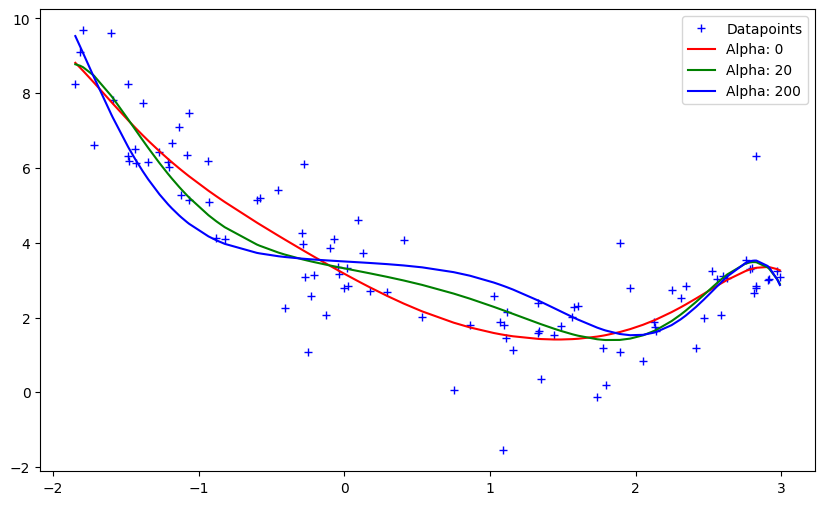

In [37]:
plt.figure(figsize=(10,6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [39]:
preds[np.argsort(x1[:, 0])]

array([9.52949442, 9.25025316, 9.06796177, 8.43213019, 7.42425582,
       7.34771745, 6.5676444 , 6.55977187, 6.49918817, 6.23955572,
       6.22315231, 5.91075812, 5.69645821, 5.29444967, 5.03345124,
       5.01094692, 4.92010108, 4.73465977, 4.67507418, 4.5472406 ,
       4.5096407 , 4.50702245, 4.17295896, 4.16495729, 4.06497247,
       3.97080062, 3.73002239, 3.71521639, 3.63946383, 3.61931728,
       3.57496803, 3.57357191, 3.57194598, 3.56794862, 3.56298737,
       3.55596607, 3.55143573, 3.52993983, 3.52302461, 3.51675779,
       3.51020591, 3.5079963 , 3.5003911 , 3.49522066, 3.49400202,
       3.47873351, 3.47029217, 3.45943065, 3.42772971, 3.39267284,
       3.34174332, 3.21337696, 3.11784017, 2.93549232, 2.87757076,
       2.84859165, 2.8383427 , 2.81717381, 2.80912855, 2.74744854,
       2.45255599, 2.45055677, 2.44338663, 2.41745294, 2.2514238 ,
       2.16162417, 2.01697494, 1.99223054, 1.9416057 , 1.72938983,
       1.67345933, 1.65230949, 1.55968573, 1.55926087, 1.52635

In [42]:
np.argsort(x1[:, 0])

array([38, 35, 62, 12, 78, 68, 39,  4, 58, 45, 20, 55, 70, 29, 30, 11, 42,
       61, 49, 80, 15, 26, 72, 98, 77, 19, 16, 14, 52, 94, 85, 83, 25,  9,
        0, 46, 41,  1, 32, 86, 21,  2, 96, 34, 81, 44, 65, 90, 63, 82, 76,
       27, 40, 28, 37, 91, 71, 13,  3, 57, 73, 10, 18, 51, 24, 59,  6, 88,
        5, 97,  7, 64, 36, 89, 56, 93, 99,  8, 33, 31, 66, 67, 74, 23, 60,
       47, 69, 75, 53, 48, 43, 95, 54, 84, 92, 22, 17, 50, 87, 79])

In [43]:
x1[:, 0]

array([-0.25103133, -0.12888923, -0.03696193,  1.1167725 , -1.48338279,
        1.60489725,  1.56334607,  1.77602153,  2.12985844, -0.26739655,
        1.33222417, -1.20596981, -1.71906634,  1.11128983, -0.58115071,
       -1.06634182, -0.60123221,  2.90505263,  1.33615146, -0.82105134,
       -1.43340912, -0.04649237,  2.82785913,  2.46682627,  1.4388519 ,
       -0.28020786, -1.06547156,  0.75000416,  1.02519985, -1.26888202,
       -1.21128809,  2.2455593 , -0.10066505,  2.14192107,  0.01880906,
       -1.81359498,  1.88947043,  1.06872593, -1.84644515, -1.48450931,
        0.86215055, -0.21090614, -1.18383478,  2.78431015,  0.09106151,
       -1.43593337, -0.22698045,  2.55905595,  2.75371191, -1.11778518,
        2.91753786,  1.3502835 , -0.45305412,  2.62814341,  2.81393834,
       -1.38326341,  1.96193408,  1.15754391, -1.47465358,  1.48617326,
        2.52458123, -1.1348241 , -1.79243811,  0.29475829,  1.79305705,
        0.12744644,  2.30736551,  2.34326295, -1.58888583,  2.58